# Kaggle Phase 4 — Drift Detection & Adaptive Streaming Evaluation

Fourth of 4 notebooks. **All drift-aware work lives here now** (moved out of Phase 3):
the chronological streaming evaluation with `DriftMonitor` (moving-average + z-score
error checks) triggering `OnlineAdapter` (error-triggered incremental fine-tuning) with
`AdaptiveThreshold` tracking a rolling confidence band, the static-vs-adaptive
comparison, plus fully instrumented per-chunk logging and an automated diagnosis of
why/when retraining stops firing.

**Requires THREE datasets attached via Add Input:**
1. `kagglephase1-output` — features/windows/masks from `kagglephase1`
2. `kagglephase2-defs` — `model_defs.py` from `kagglephase2`
3. `kagglephase3-output` — the unzipped contents of `kagglephase3_output.zip`
   (download from Phase 3's Output tab after it finishes; contains the trained
   `checkpoints/gru_h{h}_static.pt` files plus all Phase 3 metrics)

No training from scratch happens here — only loading Phase 3's checkpoints, streaming
inference, and drift-triggered incremental updates.


## Step 1: Locate All 3 Inputs + Import from model_defs.py

In [12]:
import os, sys, gc, json, time
import numpy as np
from pathlib import Path

IN_KAGGLE = os.path.exists('/kaggle')
inp = Path('/kaggle/input') if IN_KAGGLE else Path('.')

hits1 = sorted(inp.glob('**/features_injected.npy'), key=lambda p: len(p.parts))
if not hits1:
    raise FileNotFoundError(
        "Phase-1 output not found -- attach the 'kagglephase1-output' dataset via Add Input."
    )
P1 = hits1[0].parent

hits2 = sorted(inp.glob('**/model_defs.py'), key=lambda p: len(p.parts))
if not hits2:
    raise FileNotFoundError(
        "model_defs.py not found -- attach the 'kagglephase2-defs' dataset via Add Input."
    )
sys.path.insert(0, str(hits2[0].parent))

hits3 = sorted(inp.glob('**/gru_h*_static.pt'), key=lambda p: len(p.parts))
if not hits3:
    raise FileNotFoundError(
        "No trained checkpoints (gru_h*_static.pt) found -- download kagglephase3_output.zip "
        "from Phase 3's Output tab, unzip, upload the files as a Kaggle Dataset named "
        "'kagglephase3-output', and attach it via Add Input."
    )
CKPT_DIR = hits3[0].parent
available_horizons = sorted(int(p.stem.split('_h')[1].split('_')[0])
                            for p in CKPT_DIR.glob('gru_h*_static.pt'))

from model_defs import (AdaptiveGRUModel, make_loader, predict_all, compute_metrics,
                        DriftMonitor, AdaptiveThreshold, OnlineAdapter)
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Phase-1 input   : {P1}")
print(f"model_defs      : {hits2[0]}")
print(f"checkpoints dir : {CKPT_DIR}  (horizons available: {available_horizons})")
print(f"device          : {device}")

p3_metrics = sorted(inp.glob('**/all_metrics.json'), key=lambda p: len(p.parts))
if p3_metrics:
    _p3 = json.load(open(p3_metrics[0]))
    print(f"Phase-3 metrics loaded for reference: horizons {list(_p3.get('static_results', {}).keys())}")


Phase-1 input   : /kaggle/input/datasets/thanakaran/kagglephase1-output
model_defs      : /kaggle/input/datasets/thanakaran/kagglephase2-defs/model_defs.py
checkpoints dir : /kaggle/input/datasets/thanakaran/phase3-output/kagglephase3_output/checkpoints  (horizons available: [1, 2, 3])
device          : cuda
Phase-3 metrics loaded for reference: horizons ['1', '2', '3']


## Step 2: Load Phase 1 Data + Config (mirrors Phase 3's model settings)

In [13]:
fc = json.load(open(P1 / 'feature_cols.json'))
stats = json.load(open(P1 / 'normalization_stats.json'))
segments = json.load(open(P1 / 'segments.json'))   # per-container {start,end,i70,i85} -- needed by
                                                    # the Live Adaptive Window (Step 9) to keep the
                                                    # rolling-variability computation causal and
                                                    # container-scoped; not used by Steps 1-8.
TARGET_NAMES = fc['target_names']
TARGET_IDX = fc['target_idx']
TARGET_MEAN = np.array([stats[c]['mean'] for c in fc['target_columns']])
TARGET_STD  = np.array([stats[c]['std']  for c in fc['target_columns']])
FEAT_INJ = P1 / 'features_injected.npy'
windows_test = np.load(P1 / 'windows_test.npy')
spike_mask = np.load(P1 / 'spike_mask.npy')

HORIZONS = available_horizons        # e.g. [1, 2, 3] from Phase 3
HIDDEN_SIZE, NUM_LAYERS, DROPOUT = 128, 2, 0.2   # must match Phase 3's Phase3Config
EVAL_BATCH_SIZE = 512
STREAM_CHUNK = 768
ADAPT_LR, ADAPT_RECENT, ADAPT_BATCH_SIZE = 1e-4, 4096, 128
SPIKE_LOOKBACK_TAIL = 60
DEBUG_HORIZON = max(available_horizons)   # which horizon gets per-chunk debug logging

# Live Adaptive Window (Step 9) parameters -- same formula shape and bounds as the
# historical Phase 1 rule (1000 - 250*(ratio-1), clipped to [500,1000]), so the two
# are directly comparable and the model never sees a length outside what it was
# trained on. Only the REFERENCE (long-term denominator) changes: Phase 1 froze it
# at each container's training-period median; the live version recomputes it
# continuously from the stream's own causal history instead.
MIN_LOOKBACK      = 500
MAX_LOOKBACK       = 1000
SHRINK_COEF        = 250
LIVE_SHORT_WINDOW  = 120    # matches Phase 1's VAR_WIN exactly, for comparability
LIVE_LONG_WINDOW   = 2000   # rolling reference window; well within any single
                            # container's ~8,300-row length, reaching back across
                            # the test-region boundary into that container's own
                            # earlier (train/val) rows as legitimate past history --
                            # the same lookback-crosses-boundary principle Phase 1
                            # already uses for window context, just applied to the
                            # variability signal itself.

print(f"Streaming horizons: {HORIZONS} | test windows: {len(windows_test):,} | "
      f"chunk={STREAM_CHUNK} -> ~{int(np.ceil(len(windows_test)/STREAM_CHUNK))} chunks | "
      f"debug horizon: {DEBUG_HORIZON}")
print(f"Live Adaptive Window: short={LIVE_SHORT_WINDOW} long={LIVE_LONG_WINDOW} "
      f"bounds=[{MIN_LOOKBACK},{MAX_LOOKBACK}] shrink_coef={SHRINK_COEF}")


Streaming horizons: [1, 2, 3] | test windows: 33,343 | chunk=768 -> ~44 chunks | debug horizon: 3
Live Adaptive Window: short=120 long=2000 bounds=[500,1000] shrink_coef=250


## Step 3: Streaming Drift-Aware Evaluation — Static vs. Adaptive (moved from Phase 3)

Two passes per horizon over the same chronological stream of injected-test windows:
- **static**: frozen Phase-3 checkpoint.
- **adaptive**: `DriftMonitor` watches chunk-level error (EWMA + z-score vs. a frozen
  reference window); on sustained breach, `OnlineAdapter` fine-tunes on recent
  already-seen windows (their targets are in the stream's past — no future
  information; the trailing 10 windows are excluded to respect the max-horizon
  overlap). `AdaptiveThreshold` maintains a rolling P50/P90 confidence band throughout.


In [14]:
def load_static_model(h):
    ckpt = torch.load(str(CKPT_DIR / f'gru_h{h}_static.pt'), map_location=device)
    m = AdaptiveGRUModel(input_size=27, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                         dropout=DROPOUT, residual_indices=TARGET_IDX).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

def spike_window_mask(wins, horizon):
    tgt_rows = wins[:, 0] - 1 + horizon
    m = spike_mask[tgt_rows].copy()
    for i, (e, L) in enumerate(wins):
        if not m[i]:
            m[i] = spike_mask[max(e - SPIKE_LOOKBACK_TAIL, e - L):e].any()
    return m

def stream_eval(h, adaptive, windows_override=None):
    # windows_override: optional (N,2) [anchor, length] array to use INSTEAD of the
    # historical windows_test -- used by Step 10 to run the identical evaluation
    # logic against the Live Adaptive Window's lengths. Default (None) preserves
    # the exact original behavior of every existing call in this notebook.
    model = load_static_model(h)
    src_windows = windows_test if windows_override is None else windows_override
    wins = src_windows[np.argsort(src_windows[:, 0], kind='stable')]
    monitor = DriftMonitor()
    athresh = AdaptiveThreshold()
    adapter = OnlineAdapter(FEAT_INJ, TARGET_IDX, h, lr=ADAPT_LR,
                            recent=ADAPT_RECENT, batch_size=ADAPT_BATCH_SIZE)
    preds, tgts, triggers, bands = [], [], [], []
    n_chunks = int(np.ceil(len(wins) / STREAM_CHUNK))
    for ci in range(n_chunks):
        chunk = wins[ci * STREAM_CHUNK:(ci + 1) * STREAM_CHUNK]
        loader = make_loader(FEAT_INJ, chunk, h, TARGET_IDX, batch_size=EVAL_BATCH_SIZE)
        p, t = predict_all(model, loader, device)
        preds.append(p); tgts.append(t)
        err = float(((p - t) ** 2).mean())
        bands.append(athresh.update(np.abs(p - t).mean(axis=1)))
        if adaptive and monitor.update(err):
            seen = wins[:ci * STREAM_CHUNK + len(chunk)][:-10]
            if len(seen) >= 512:
                adapter.adapt(model, seen, device)
                triggers.append(ci)
                monitor.hits = 0
    preds, tgts = np.concatenate(preds), np.concatenate(tgts)
    sm = spike_window_mask(wins, h)
    out = {'overall': compute_metrics(preds, tgts, TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'spike':   compute_metrics(preds[sm], tgts[sm], TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'normal':  compute_metrics(preds[~sm], tgts[~sm], TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'n_spike_windows': int(sm.sum()), 'n_windows': len(wins),
           'adapt_triggers': triggers, 'n_updates': adapter.n_updates,
           'final_band': bands[-1]}
    del model
    torch.cuda.empty_cache(); gc.collect()
    return out

stream_results = {}
for h in HORIZONS:
    print(f"\n--- horizon {h}: static pass ---")
    t0 = time.time()
    r_static = stream_eval(h, adaptive=False)
    print(f"  overall MAPE={r_static['overall']['mape_mean']:.2f}% | "
          f"spike={r_static['spike']['mape_mean']:.2f}% ({r_static['n_spike_windows']:,} windows) | "
          f"normal={r_static['normal']['mape_mean']:.2f}% | {time.time()-t0:.0f}s")
    print(f"--- horizon {h}: adaptive pass ---")
    t0 = time.time()
    r_adapt = stream_eval(h, adaptive=True)
    print(f"  overall MAPE={r_adapt['overall']['mape_mean']:.2f}% | "
          f"spike={r_adapt['spike']['mape_mean']:.2f}% | normal={r_adapt['normal']['mape_mean']:.2f}% | "
          f"updates={r_adapt['n_updates']} at chunks {r_adapt['adapt_triggers']} | {time.time()-t0:.0f}s")
    stream_results[h] = {'static': r_static, 'adaptive': r_adapt}



--- horizon 1: static pass ---
  overall MAPE=0.13% | spike=0.24% (10,028 windows) | normal=0.09% | 9s
--- horizon 1: adaptive pass ---
  overall MAPE=0.12% | spike=0.22% | normal=0.07% | updates=3 at chunks [11, 13, 15] | 17s

--- horizon 2: static pass ---
  overall MAPE=0.21% | spike=0.35% (10,119 windows) | normal=0.15% | 8s
--- horizon 2: adaptive pass ---
  overall MAPE=0.20% | spike=0.34% | normal=0.14% | updates=8 at chunks [10, 12, 14, 16, 21, 23, 25, 32] | 29s

--- horizon 3: static pass ---
  overall MAPE=0.26% | spike=0.46% (10,210 windows) | normal=0.17% | 8s
--- horizon 3: adaptive pass ---
  overall MAPE=0.26% | spike=0.45% | normal=0.18% | updates=9 at chunks [10, 12, 14, 16, 20, 22, 24, 26, 28] | 32s


## Step 4: Static vs. Adaptive Comparison Table + Verdict

In [15]:
print("="*74)
print("STATIC vs. ADAPTIVE -- burst-injected test stream, MAPE % per target")
print("="*74)
for h in HORIZONS:
    sr = stream_results[h]
    for regime in ('spike', 'normal'):
        n_reg = sr['static']['n_spike_windows'] if regime == 'spike' \
            else sr['static']['n_windows'] - sr['static']['n_spike_windows']
        print(f"\nhorizon {h}, {regime.upper()} windows ({n_reg:,}):")
        print(f"  {'target':<18} {'GRU-static':>11} {'GRU-adaptive':>13}")
        for n in TARGET_NAMES:
            print(f"  {n:<18} {sr['static'][regime][n]['mape']:>10.2f}% "
                  f"{sr['adaptive'][regime][n]['mape']:>12.2f}%")

print()
print("="*74)
print("VERDICT SUMMARY")
print("="*74)
for h in HORIZONS:
    sr = stream_results[h]
    d_spike = sr['static']['spike']['mape_mean'] - sr['adaptive']['spike']['mape_mean']
    d_norm  = sr['static']['normal']['mape_mean'] - sr['adaptive']['normal']['mape_mean']
    print(f"h={h}: adaptation changed spike-window MAPE by {-d_spike:+.2f} pts "
          f"(static {sr['static']['spike']['mape_mean']:.2f}% -> adaptive {sr['adaptive']['spike']['mape_mean']:.2f}%), "
          f"normal windows by {-d_norm:+.2f} pts, with {sr['adaptive']['n_updates']} online update(s)")
print()
print("Positive spike-window improvements with non-degraded normal windows = the drift-aware")
print("mechanism doing its job. Report whatever the numbers actually show.")


STATIC vs. ADAPTIVE -- burst-injected test stream, MAPE % per target

horizon 1, SPIKE windows (10,028):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.07%         0.09%
  mem_usage                0.29%         0.27%
  mem_working_set          0.29%         0.26%
  mem_rss                  0.29%         0.26%

horizon 1, NORMAL windows (23,315):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.01%         0.02%
  mem_usage                0.11%         0.08%
  mem_working_set          0.11%         0.08%
  mem_rss                  0.11%         0.09%

horizon 2, SPIKE windows (10,119):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.17%         0.23%
  mem_usage                0.42%         0.38%
  mem_working_set          0.42%         0.38%
  mem_rss                  0.41%         0.37%

horizon 2, NORMAL windows (23,224):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.07% 

## Step 5: Instrumented Per-Chunk Debug — Why Does Retraining Stop Firing?

Re-runs the adaptive pass for `DEBUG_HORIZON` with every internal `DriftMonitor` value
logged per chunk (raw error, EWMA, frozen reference mean/std, z-score, consecutive-hit
counter), plus a parameter checksum before/after each triggered adaptation proving the
weights actually changed.


In [16]:
wins = windows_test[np.argsort(windows_test[:, 0], kind="stable")]
model = load_static_model(DEBUG_HORIZON)
monitor = DriftMonitor()   # defaults: ewma_alpha=0.3, z_threshold=3.0, warmup_chunks=8, sustain=2
athresh = AdaptiveThreshold()
adapter = OnlineAdapter(FEAT_INJ, TARGET_IDX, DEBUG_HORIZON, lr=ADAPT_LR,
                        recent=ADAPT_RECENT, batch_size=ADAPT_BATCH_SIZE)

def param_checksum(m):
    return float(sum(p.detach().sum().item() for p in m.parameters()))

log_rows = []
n_chunks = int(np.ceil(len(wins) / STREAM_CHUNK))
print(f"{'chunk':>5} {'n_win':>6} {'mse_err':>10} {'ewma':>10} {'ref_mu':>10} {'ref_sd':>10} "
      f"{'z_score':>8} {'hits':>5} {'drifting':>9} {'triggered':>10} {'weights_changed':>16}")
print("-" * 118)

for ci in range(n_chunks):
    chunk = wins[ci * STREAM_CHUNK:(ci + 1) * STREAM_CHUNK]
    loader = make_loader(FEAT_INJ, chunk, DEBUG_HORIZON, TARGET_IDX, batch_size=EVAL_BATCH_SIZE)
    p, t = predict_all(model, loader, device)
    err = float(((p - t) ** 2).mean())
    lo, hi = athresh.update(np.abs(p - t).mean(axis=1))

    in_warmup = len(monitor.ref) < monitor.warmup
    drifting = monitor.update(err)

    if len(monitor.ref) >= monitor.warmup:
        ref_mu = float(np.mean(monitor.ref))
        ref_sd = float(np.std(monitor.ref)) or 1e-12
        z = (monitor.ewma - ref_mu) / ref_sd
    else:
        ref_mu = ref_sd = z = float("nan")

    triggered = False
    weights_changed = "n/a"
    if drifting:
        seen = wins[:ci * STREAM_CHUNK + len(chunk)][:-10]
        if len(seen) >= 512:
            before = param_checksum(model)
            adapter.adapt(model, seen, device)
            after = param_checksum(model)
            triggered = True
            weights_changed = "YES" if abs(after - before) > 1e-9 else "NO (unexpected!)"
            monitor.hits = 0

    log_rows.append(dict(chunk=ci, n_windows=len(chunk), mse_err=err, ewma=monitor.ewma,
                         ref_mu=ref_mu, ref_sd=ref_sd, z_score=z, hits=monitor.hits,
                         in_warmup=in_warmup, drifting=drifting, triggered=triggered,
                         weights_changed=weights_changed, athresh_lo=lo, athresh_hi=hi))

    z_str = f"{z:8.2f}" if z == z else f"{'--':>8}"
    print(f"{ci:>5} {len(chunk):>6} {err:>10.6f} {monitor.ewma:>10.6f} "
          f"{ref_mu:>10.6f} {ref_sd:>10.6f} "
          f"{z_str} {monitor.hits:>5} {str(drifting):>9} {str(triggered):>10} {weights_changed:>16}")

print()
n_triggers = sum(r["triggered"] for r in log_rows)
last_trigger = max([r["chunk"] for r in log_rows if r["triggered"]], default=None)
print(f"Total triggers: {n_triggers} | last trigger at chunk {last_trigger} of {n_chunks-1} total chunks")


chunk  n_win    mse_err       ewma     ref_mu     ref_sd  z_score  hits  drifting  triggered  weights_changed
----------------------------------------------------------------------------------------------------------------------
    0    768   0.000798   0.000798        nan        nan       --     0     False      False              n/a
    1    768   0.000615   0.000743        nan        nan       --     0     False      False              n/a
    2    768   0.000622   0.000707        nan        nan       --     0     False      False              n/a
    3    768   0.000585   0.000670        nan        nan       --     0     False      False              n/a
    4    768   0.000639   0.000661        nan        nan       --     0     False      False              n/a
    5    768   0.000591   0.000640        nan        nan       --     0     False      False              n/a
    6    768   0.000482   0.000592        nan        nan       --     0     False      False              n/a
 

## Step 6: Visualize — Error, EWMA, Reference Threshold, Trigger Points

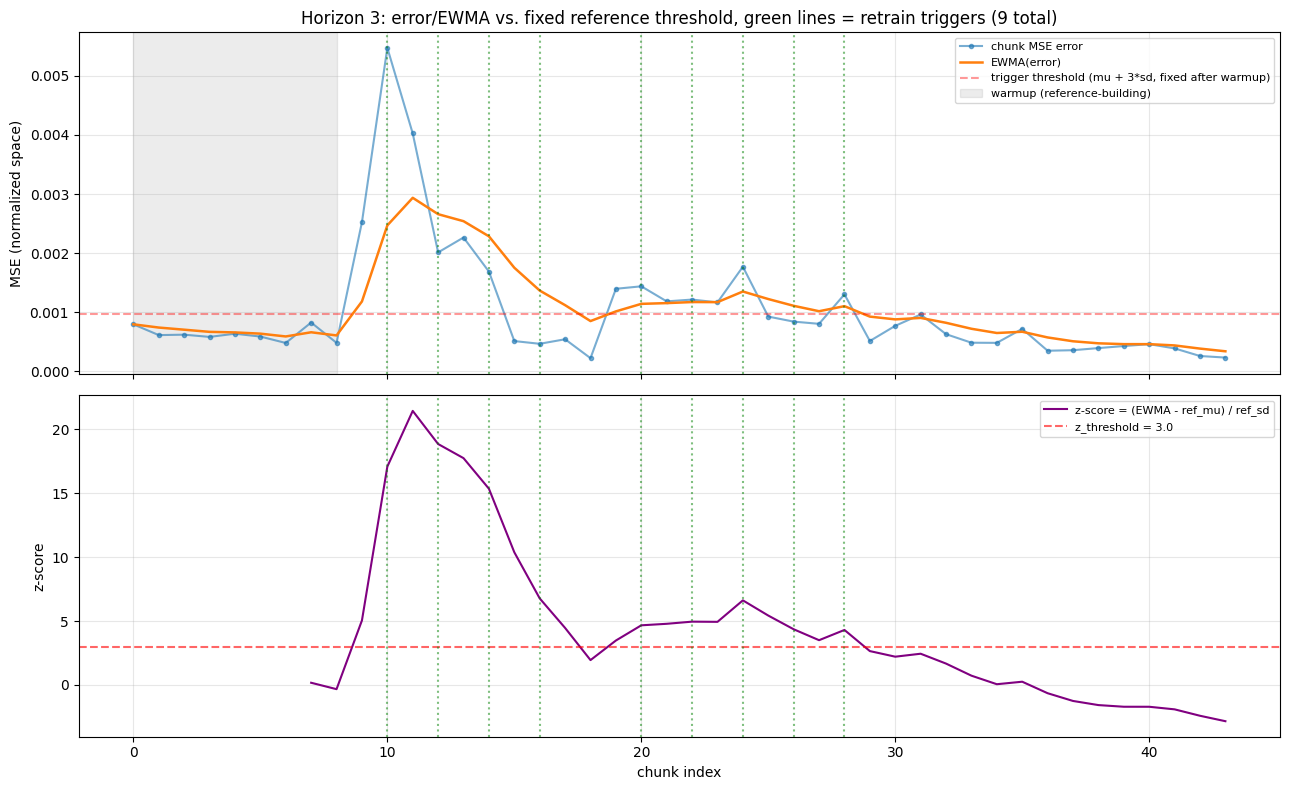

Saved /kaggle/working/drift_debug_h3.png


In [17]:
import matplotlib.pyplot as plt

chunks = [r['chunk'] for r in log_rows]
errs = [r['mse_err'] for r in log_rows]
ewmas = [r['ewma'] for r in log_rows]
zscores = [r['z_score'] for r in log_rows]
trig_chunks = [r['chunk'] for r in log_rows if r['triggered']]
warmup_end = next((r['chunk'] for r in log_rows if not r['in_warmup']), 0)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(chunks, errs, label='chunk MSE error', alpha=0.6, marker='.')
axes[0].plot(chunks, ewmas, label='EWMA(error)', linewidth=1.8)
for r in log_rows:
    if not r['in_warmup'] and r['ref_mu'] == r['ref_mu']:
        thresh = r['ref_mu'] + monitor.z * r['ref_sd']
        axes[0].axhline(thresh, color='red', linestyle='--', alpha=0.4,
                        label='trigger threshold (mu + 3*sd, fixed after warmup)')
        break
axes[0].axvspan(0, warmup_end, color='gray', alpha=0.15, label='warmup (reference-building)')
for c in trig_chunks:
    axes[0].axvline(c, color='green', alpha=0.5, linestyle=':')
axes[0].set_ylabel('MSE (normalized space)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title(f'Horizon {DEBUG_HORIZON}: error/EWMA vs. fixed reference threshold, '
                  f'green lines = retrain triggers ({len(trig_chunks)} total)')
axes[0].grid(alpha=0.3)

axes[1].plot(chunks, zscores, label='z-score = (EWMA - ref_mu) / ref_sd', color='purple')
axes[1].axhline(monitor.z, color='red', linestyle='--', alpha=0.6, label=f'z_threshold = {monitor.z}')
for c in trig_chunks:
    axes[1].axvline(c, color='green', alpha=0.5, linestyle=':')
axes[1].set_xlabel('chunk index')
axes[1].set_ylabel('z-score')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_path = (Path('/kaggle/working') if IN_KAGGLE else Path('.')) / f'drift_debug_h{DEBUG_HORIZON}.png'
plt.savefig(save_path, dpi=100)
plt.show()
print(f"Saved {save_path}")


## Step 7: Automated Diagnosis — Stabilized Model or Detector Limitation?

Tests the two hypotheses directly against the logged data:
- **Genuinely stabilized**: after the last trigger, z-score stays consistently below
  threshold (a single stray near-miss counts as noise, matching the monitor's own
  `sustain=2` convention).
- **Detector limitation**: two or more chunks after the last trigger exceed the
  threshold without triggering — real elevated error the monitor failed to act on.


In [18]:
if last_trigger is None:
    print("No triggers fired at all -- inspect the full log table above for why "
          "(check whether z-scores ever approached the threshold).")
else:
    after = [r for r in log_rows if r['chunk'] > last_trigger]
    above_thresh_after = [r for r in after if r['z_score'] == r['z_score'] and r['z_score'] > monitor.z]
    mean_z_after = float(np.nanmean([r['z_score'] for r in after]))

    print(f"Chunks after the last trigger (chunk {last_trigger}): {len(after)}")
    print(f"Mean z-score in that region: {mean_z_after:.2f}  (threshold = {monitor.z})")
    print(f"Chunks where z-score EXCEEDED the threshold but did not trigger: {len(above_thresh_after)}")
    if above_thresh_after:
        print("  at chunks:", [r['chunk'] for r in above_thresh_after])

    print()
    if len(above_thresh_after) < 2 and mean_z_after < monitor.z * 0.5:
        print("DIAGNOSIS: error genuinely stabilized well below the reference threshold after "
              "the last adaptation -- the mechanism worked as intended and further correction "
              "was not needed for the rest of the stream.")
        if len(above_thresh_after) == 1:
            print(f"  (one isolated near-miss at chunk {above_thresh_after[0]['chunk']} -- "
                  f"consistent with normal noise, not a sustained pattern the monitor missed.)")
    elif len(above_thresh_after) >= 2:
        print("DIAGNOSIS: multiple elevated-error chunks exist after the last trigger that the "
              "monitor did NOT act on -- consistent with the consecutive-hit requirement "
              "(sustain=2) or the frozen reference window missing genuine later drift. "
              "The detector has a real sensitivity limitation, not just a stabilized model.")
    else:
        print("DIAGNOSIS: mixed signal -- z-score stayed below threshold but not dramatically so. "
              "Inspect the Step 6 plot directly to judge whether this looks like stabilization "
              "or a detector that's just barely missing real fluctuation.")


Chunks after the last trigger (chunk 28): 15
Mean z-score in that region: -0.27  (threshold = 3.0)
Chunks where z-score EXCEEDED the threshold but did not trigger: 0

DIAGNOSIS: error genuinely stabilized well below the reference threshold after the last adaptation -- the mechanism worked as intended and further correction was not needed for the rest of the stream.


## Step 8: Save Phase 4 Results (zipped download)

In [19]:
import zipfile

out_dir = Path('/kaggle/working') if IN_KAGGLE else Path('.')
results = {
    'horizons': HORIZONS,
    'debug_horizon': DEBUG_HORIZON,
    'stream_results': stream_results,
    'debug_log': log_rows,
    'settings': {'stream_chunk': STREAM_CHUNK, 'adapt_lr': ADAPT_LR,
                 'adapt_recent': ADAPT_RECENT, 'adapt_batch_size': ADAPT_BATCH_SIZE,
                 'eval_batch_size': EVAL_BATCH_SIZE, 'spike_lookback_tail': SPIKE_LOOKBACK_TAIL},
}
# Additive: only present if Step 9/10 (Live Adaptive Window) ran in this session.
if 'stream_results_live' in globals():
    results['stream_results_live'] = stream_results_live
    results['live_window_settings'] = {'live_short_window': LIVE_SHORT_WINDOW,
                                       'live_long_window': LIVE_LONG_WINDOW,
                                       'shrink_coef': SHRINK_COEF,
                                       'min_lookback': MIN_LOOKBACK, 'max_lookback': MAX_LOOKBACK}
    results['live_window_lengths_at_test_anchors'] = windows_test_live[:, 1].tolist()
json_path = out_dir / 'phase4_results.json'
with open(json_path, 'w') as f:
    json.dump(results, f, indent=1, default=float)

zip_path = out_dir / 'kagglephase4_output.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write(json_path, json_path.name)
    png = out_dir / f'drift_debug_h{DEBUG_HORIZON}.png'
    if png.exists():
        z.write(png, png.name)

print(f"Saved {json_path.name} and {zip_path.name} ({zip_path.stat().st_size/1e6:.2f} MB)")
print("Download from the Output tab -- contains the full static-vs-adaptive streaming results,")
print("the per-chunk drift-detection debug log, and the diagnosis plot.")


Saved phase4_results.json and kagglephase4_output.zip (0.13 MB)
Download from the Output tab -- contains the full static-vs-adaptive streaming results,
the per-chunk drift-detection debug log, and the diagnosis plot.


## Step 9: Live Adaptive Sliding Window — Computation

Implements the proposal's "adaptive sliding window ... adjusts based on workload
variability" requirement in the strict, live sense -- upgraded from the historical
version used in Steps 1-8 (and by Phase 1/3), which computes window length **once**
from training-period statistics and never revisits it.

**Mechanism:** same short-term signal as the historical rule (rolling std of
normalized cpu_usage, 120-step window) and the same formula shape/bounds
(`clip(1000 - 250*(ratio-1), 500, 1000)`), but the **reference** is now a rolling
median over a longer causal window (2,000 steps) instead of a frozen training-only
snapshot -- so it continuously reflects what's been recently typical, not what was
typical back during training. Independent of `DriftMonitor`: no prediction error,
model output, or drift state is used anywhere in this computation -- `DriftMonitor`
keeps its existing, unchanged role (drift detection -> triggering `OnlineAdapter`
in Steps 3/5, untouched by this section).

**Causality:** for anchor `end`, the decision uses only `feat_arr` rows up to and
including `end-1` (the last observed step) -- verified below and consistent with
every other "last observed value" use in this project (e.g. the residual anchor).
**Bounds:** the same [500, 1000] range as always, verified with an explicit assertion.


In [20]:
import pandas as pd

def compute_live_window_lengths(feat_arr, segments, cpu_col_idx, anchors,
                                 short_window=LIVE_SHORT_WINDOW, long_window=LIVE_LONG_WINDOW,
                                 shrink_coef=SHRINK_COEF, min_len=MIN_LOOKBACK, max_len=MAX_LOOKBACK):
    """Live, causal window length per anchor. Uses only feat_arr rows strictly
    before each anchor's target -- no DriftMonitor, no prediction error, no future
    information anywhere in this function."""
    cpu_col = np.asarray(feat_arr[:, cpu_col_idx], dtype=np.float64)
    n_rows = len(cpu_col)
    live_len_per_row = np.full(n_rows, float(max_len), dtype=np.float64)  # warmup default = max
    container_start_per_row = np.zeros(n_rows, dtype=np.int64)

    for seg in segments.values():
        s, e = seg['start'], seg['end']
        container_start_per_row[s:e] = s
        series = pd.Series(cpu_col[s:e])
        short_std = series.rolling(short_window, min_periods=short_window).std()
        long_ref = short_std.rolling(long_window, min_periods=long_window).median()
        # .mask (not .where) -- must only replace a genuinely tiny-but-defined
        # reference with a floor value; .where(long_ref > 1e-9, ...) would also
        # silently replace NaN (long_ref > 1e-9 is False for NaN too), destroying
        # the NaN that the fillna(max_len) warmup default below depends on.
        long_ref_safe = long_ref.mask((long_ref <= 1e-9) & long_ref.notna(), 1e-9)
        ratio = short_std / long_ref_safe
        length = (max_len - shrink_coef * (ratio - 1.0)).clip(lower=min_len, upper=max_len)
        length = length.fillna(float(max_len))  # not enough causal history yet -> default max
        live_len_per_row[s:e] = length.values

    # "Current observation" for anchor `end` is row end-1 (last observed step before
    # the prediction gap) -- same convention as x[:, -1, ...] used elsewhere.
    last_obs_row = anchors - 1
    raw_length = live_len_per_row[last_obs_row]

    # Cap so length never exceeds what's actually available back to this container's
    # start. Phase 1 already guarantees every anchor in windows_test has >=500 rows
    # available, so this can only bind above min_len, never push below it.
    available = anchors - container_start_per_row[last_obs_row]
    capped_length = np.minimum(raw_length, available)
    final_length = np.clip(np.round(capped_length), min_len, max_len).astype(np.int32)
    return final_length

feat_arr_live = np.load(FEAT_INJ, mmap_mode='r')
cpu_col_idx = TARGET_IDX[0]   # cpu_usage's index within the 27-feature array

live_lengths = compute_live_window_lengths(feat_arr_live, segments, cpu_col_idx, windows_test[:, 0])
windows_test_live = np.stack([windows_test[:, 0], live_lengths], axis=1).astype(np.int32)

hist_lengths = windows_test[:, 1]
print(f"Historical (Phase 1) lengths -- min/mean/max: "
      f"{hist_lengths.min()}/{hist_lengths.mean():.0f}/{hist_lengths.max()}")
print(f"Live       (Phase 4) lengths -- min/mean/max: "
      f"{live_lengths.min()}/{live_lengths.mean():.0f}/{live_lengths.max()}")
n_diff = int((live_lengths != hist_lengths).sum())
print(f"Anchors where live differs from historical: {n_diff:,} / {len(hist_lengths):,} "
      f"({100*n_diff/len(hist_lengths):.1f}%)")
assert live_lengths.min() >= MIN_LOOKBACK and live_lengths.max() <= MAX_LOOKBACK, \
    "live window length escaped the [500,1000] bound -- must never happen"
print(f"Bounds check: all lengths within [{MIN_LOOKBACK},{MAX_LOOKBACK}]  PASS")


Historical (Phase 1) lengths -- min/mean/max: 500/809/1000
Live       (Phase 4) lengths -- min/mean/max: 500/811/1000
Anchors where live differs from historical: 8,339 / 33,343 (25.0%)
Bounds check: all lengths within [500,1000]  PASS


## Step 10: Live-Window Streaming Evaluation — Static vs. Adaptive

Re-runs the identical `stream_eval` logic from Step 3 -- same model, same
`DriftMonitor`/`OnlineAdapter`/`AdaptiveThreshold`, same chunking -- against
`windows_test_live` instead of the historical `windows_test`. This is the same
function, not a copy (`stream_eval`'s only change was the one optional parameter
added in Step 3), so any difference in the results below is attributable to the
window-length source alone, not to any other change in the evaluation logic.


In [21]:
stream_results_live = {}
for h in HORIZONS:
    print(f"\n--- horizon {h}: LIVE-WINDOW static pass ---")
    t0 = time.time()
    r_static_live = stream_eval(h, adaptive=False, windows_override=windows_test_live)
    print(f"  overall MAPE={r_static_live['overall']['mape_mean']:.2f}% | "
          f"spike={r_static_live['spike']['mape_mean']:.2f}% | "
          f"normal={r_static_live['normal']['mape_mean']:.2f}% | {time.time()-t0:.0f}s")
    print(f"--- horizon {h}: LIVE-WINDOW adaptive pass ---")
    t0 = time.time()
    r_adapt_live = stream_eval(h, adaptive=True, windows_override=windows_test_live)
    print(f"  overall MAPE={r_adapt_live['overall']['mape_mean']:.2f}% | "
          f"spike={r_adapt_live['spike']['mape_mean']:.2f}% | "
          f"normal={r_adapt_live['normal']['mape_mean']:.2f}% | "
          f"updates={r_adapt_live['n_updates']} at chunks {r_adapt_live['adapt_triggers']} | {time.time()-t0:.0f}s")
    stream_results_live[h] = {'static': r_static_live, 'adaptive': r_adapt_live}



--- horizon 1: LIVE-WINDOW static pass ---
  overall MAPE=0.13% | spike=0.24% | normal=0.09% | 8s
--- horizon 1: LIVE-WINDOW adaptive pass ---
  overall MAPE=0.12% | spike=0.22% | normal=0.07% | updates=3 at chunks [11, 13, 15] | 16s

--- horizon 2: LIVE-WINDOW static pass ---
  overall MAPE=0.21% | spike=0.35% | normal=0.15% | 8s
--- horizon 2: LIVE-WINDOW adaptive pass ---
  overall MAPE=0.20% | spike=0.34% | normal=0.14% | updates=9 at chunks [10, 12, 14, 16, 21, 23, 25, 27, 31] | 32s

--- horizon 3: LIVE-WINDOW static pass ---
  overall MAPE=0.26% | spike=0.46% | normal=0.17% | 8s
--- horizon 3: LIVE-WINDOW adaptive pass ---
  overall MAPE=0.26% | spike=0.45% | normal=0.18% | updates=9 at chunks [10, 12, 14, 16, 20, 22, 24, 26, 28] | 32s


## Step 11: Validation — Statistics, Histogram, Time Series, Accuracy Comparison

Reports whatever the live window actually did and whatever effect it actually had --
no adjustment toward a more favorable result.


Example live window lengths across the stream:
    anchor  historical_len   live_len
      7056            1000       1000
     24857            1000       1000
     49729             500        500
     74602             500        500
     99474            1000       1000
    124348             500        500
    149218            1000       1000
    174086            1000       1000
    198955             500        500
    223820             500        500

Historical: min=500 mean=809.3 median=995 max=1000 std=236.9
Live:       min=500 mean=810.6 median=1000 max=1000 std=237.3
At floor (500):   historical=35.6%  live=35.5%
At ceiling (1000): historical=39.9%  live=51.7%


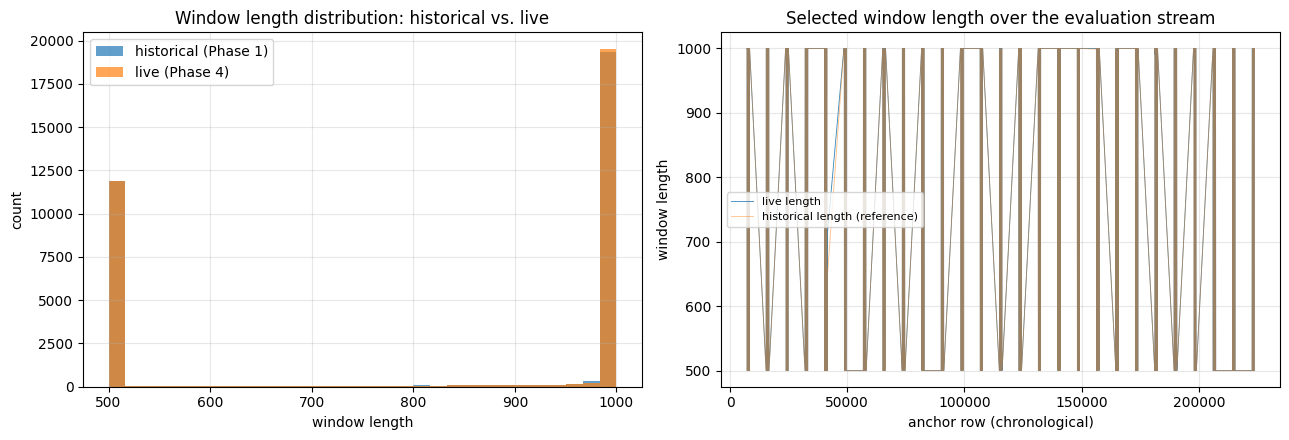

Saved /kaggle/working/live_window_validation.png

FINAL COMPARISON -- historical (Phase 1) vs. live (Phase 4) adaptive window, MAPE %

horizon 1:
  regime    hist-static  hist-adaptive  live-static  live-adaptive
  overall         0.13%          0.12%        0.13%          0.12%
  spike           0.24%          0.22%        0.24%          0.22%
  normal          0.09%          0.07%        0.09%          0.07%

horizon 2:
  regime    hist-static  hist-adaptive  live-static  live-adaptive
  overall         0.21%          0.20%        0.21%          0.20%
  spike           0.35%          0.34%        0.35%          0.34%
  normal          0.15%          0.14%        0.15%          0.14%

horizon 3:
  regime    hist-static  hist-adaptive  live-static  live-adaptive
  overall         0.26%          0.26%        0.26%          0.26%
  spike           0.46%          0.45%        0.46%          0.45%
  normal          0.17%          0.18%        0.17%          0.18%

Reported exactly as obser

In [22]:
import matplotlib.pyplot as plt

# 1) Example live lengths at several points across the stream
sample_idx = np.linspace(0, len(windows_test_live) - 1, 10, dtype=int)
print("Example live window lengths across the stream:")
print(f"{'anchor':>10} {'historical_len':>15} {'live_len':>10}")
for i in sample_idx:
    print(f"{windows_test[i,0]:>10} {windows_test[i,1]:>15} {windows_test_live[i,1]:>10}")

# 2) Summary statistics
print(f"\nHistorical: min={hist_lengths.min()} mean={hist_lengths.mean():.1f} "
      f"median={np.median(hist_lengths):.0f} max={hist_lengths.max()} std={hist_lengths.std():.1f}")
print(f"Live:       min={live_lengths.min()} mean={live_lengths.mean():.1f} "
      f"median={np.median(live_lengths):.0f} max={live_lengths.max()} std={live_lengths.std():.1f}")
print(f"At floor (500):   historical={100*(hist_lengths==MIN_LOOKBACK).mean():.1f}%  "
      f"live={100*(live_lengths==MIN_LOOKBACK).mean():.1f}%")
print(f"At ceiling (1000): historical={100*(hist_lengths==MAX_LOOKBACK).mean():.1f}%  "
      f"live={100*(live_lengths==MAX_LOOKBACK).mean():.1f}%")

# 3) Histogram + 4) time series of live window length over the stream
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(hist_lengths, bins=30, alpha=0.7, label='historical (Phase 1)', color='tab:blue')
axes[0].hist(live_lengths, bins=30, alpha=0.7, label='live (Phase 4)', color='tab:orange')
axes[0].set_xlabel('window length'); axes[0].set_ylabel('count')
axes[0].set_title('Window length distribution: historical vs. live')
axes[0].legend(); axes[0].grid(alpha=0.3)

order = np.argsort(windows_test_live[:, 0], kind='stable')
axes[1].plot(windows_test_live[order, 0], windows_test_live[order, 1],
             linewidth=0.6, alpha=0.9, label='live length')
axes[1].plot(windows_test[order, 0], windows_test[order, 1],
             linewidth=0.6, alpha=0.5, label='historical length (reference)')
axes[1].set_xlabel('anchor row (chronological)'); axes[1].set_ylabel('window length')
axes[1].set_title('Selected window length over the evaluation stream')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
save_path = (Path('/kaggle/working') if IN_KAGGLE else Path('.')) / 'live_window_validation.png'
plt.savefig(save_path, dpi=100)
plt.show()
print(f"Saved {save_path}")

# 5) Final 4-way comparison
print()
print("="*90)
print("FINAL COMPARISON -- historical (Phase 1) vs. live (Phase 4) adaptive window, MAPE %")
print("="*90)
for h in HORIZONS:
    sh, sl = stream_results[h], stream_results_live[h]
    print(f"\nhorizon {h}:")
    print(f"  {'regime':<8} {'hist-static':>12} {'hist-adaptive':>14} {'live-static':>12} {'live-adaptive':>14}")
    for regime in ('overall', 'spike', 'normal'):
        print(f"  {regime:<8} {sh['static'][regime]['mape_mean']:>11.2f}% "
              f"{sh['adaptive'][regime]['mape_mean']:>13.2f}% "
              f"{sl['static'][regime]['mape_mean']:>11.2f}% "
              f"{sl['adaptive'][regime]['mape_mean']:>13.2f}%")

print()
print("Reported exactly as observed -- no adjustment toward a more favorable result.")


## Step 12 (Optional): Export a Self-Contained Production Model File

**Format choice: `.pt` (PyTorch's native `torch.save`), not `.pkl`/joblib.**
`torch.save` is PyTorch's own recommended serialization -- it already uses pickle
internally but adds device-mapping safety and proper tensor storage that raw
pickle/joblib lack. Raw pickle/joblib is the correct choice for scikit-learn
estimators; this project has none, so that format doesn't apply here (this exact
question was addressed earlier in the project's own history).

**What this closes, versus the existing `checkpoints/gru_h{h}_static.pt` files:**
those files hold only `{model_state_dict, epoch, val_loss}` -- no architecture
config, no normalization stats, no feature schema. Reloading them requires knowing
the exact constructor arguments (especially `residual_indices`) from *outside* the
file; get that wrong and the model loads silently with no error, producing garbage
(a real, previously-documented failure mode of this project). This step produces a
**single downloadable file that is fully self-describing** -- everything needed to
load and run the model is bundled inside it.

**Which weights get exported:** the original static Phase 3 checkpoints, loaded
fresh from `CKPT_DIR`, **not** whatever state a model was left in after Phase 4's
online-adaptation simulation. The adapted weights from Step 3/10 are a one-off
byproduct of simulating a specific evaluation stream, not a stable, reproducible
artifact -- the static checkpoint is the correct "production model."

**Optional:** toggle `EXPORT_PRODUCTION_MODEL = False` below to skip this step;
nothing else in the notebook depends on it.


In [23]:
EXPORT_PRODUCTION_MODEL = True   # set False to skip this optional export

if EXPORT_PRODUCTION_MODEL:
    production_bundle = {
        'format_version': 1,
        'framework': 'pytorch',
        'torch_version': torch.__version__,
        'architecture': {
            'class': 'AdaptiveGRUModel',
            'input_size': 27,
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'dropout': DROPOUT,
            'residual_indices': TARGET_IDX,
        },
        'targets': {
            'target_names': TARGET_NAMES,
            'target_columns': fc['target_columns'],
            'target_idx': TARGET_IDX,
            'target_mean': TARGET_MEAN.tolist(),
            'target_std': TARGET_STD.tolist(),
        },
        'feature_cols': fc['feature_cols'],
        'window_bounds': {'min_lookback': MIN_LOOKBACK, 'max_lookback': MAX_LOOKBACK},
        'horizons': {},
    }
    for h in HORIZONS:
        ckpt = torch.load(str(CKPT_DIR / f'gru_h{h}_static.pt'), map_location='cpu')
        production_bundle['horizons'][h] = {
            'model_state_dict': ckpt['model_state_dict'],
            'epoch': ckpt.get('epoch'),
            'val_loss': ckpt.get('val_loss'),
            'horizon_seconds': h * 15,
        }

    out_dir = Path('/kaggle/working') if IN_KAGGLE else Path('.')
    export_path = out_dir / 'production_model.pt'
    torch.save(production_bundle, export_path)

    print(f"Saved self-contained production model: {export_path} "
          f"({export_path.stat().st_size/1e6:.2f} MB)")
    print(f"Horizons bundled: {list(production_bundle['horizons'])} "
          f"({[h*15 for h in production_bundle['horizons']]} seconds ahead)")
    print()
    print("This single file is sufficient to load and run inference WITHOUT needing")
    print("feature_cols.json or normalization_stats.json separately -- architecture")
    print("config, per-horizon weights, target normalization stats, and the feature")
    print("schema are all bundled together.")
    print()
    print("Load example:")
    print("  bundle = torch.load('production_model.pt', map_location=device)")
    print("  arch = bundle['architecture']")
    print("  model = AdaptiveGRUModel(input_size=arch['input_size'],")
    print("                          hidden_size=arch['hidden_size'],")
    print("                          num_layers=arch['num_layers'],")
    print("                          dropout=arch['dropout'],")
    print("                          residual_indices=arch['residual_indices'])")
    print("  model.load_state_dict(bundle['horizons'][1]['model_state_dict'])  # horizon=1")
    print("  model.eval()")
    print("  target_mean = np.array(bundle['targets']['target_mean'])")
    print("  target_std  = np.array(bundle['targets']['target_std'])")
else:
    print("Production model export skipped (EXPORT_PRODUCTION_MODEL = False).")


Saved self-contained production model: /kaggle/working/production_model.pt (2.02 MB)
Horizons bundled: [1, 2, 3] ([15, 30, 45] seconds ahead)

This single file is sufficient to load and run inference WITHOUT needing
feature_cols.json or normalization_stats.json separately -- architecture
config, per-horizon weights, target normalization stats, and the feature
schema are all bundled together.

Load example:
  bundle = torch.load('production_model.pt', map_location=device)
  arch = bundle['architecture']
  model = AdaptiveGRUModel(input_size=arch['input_size'],
                          hidden_size=arch['hidden_size'],
                          num_layers=arch['num_layers'],
                          dropout=arch['dropout'],
                          residual_indices=arch['residual_indices'])
  model.load_state_dict(bundle['horizons'][1]['model_state_dict'])  # horizon=1
  model.eval()
  target_mean = np.array(bundle['targets']['target_mean'])
  target_std  = np.array(bundle['targets']['